# Titanic Survival Prediction System

# Model Training

## Objectives

- Prepare the cleaned dataset
- Train multiple machine learning models
- Compare their performance
- Select the best model

## 1. Import Libraries

In [49]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import accuracy_score

## 2. Load Dataset

In [50]:
df = pd.read_csv("../data/Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Data Preprocessing

In [51]:
# Drop unnecessary columns
df.drop(
    columns=["PassengerId", "Name", "Ticket", "Cabin"],
    inplace=True
)

In [52]:
# Handle Missing Values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [53]:
# Encode Categorical Columns
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})
df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

## 4. Prepare Features and Target

In [54]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 5. Train Machine Learning Models

In [56]:
# Logistic Regression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_accuracy = accuracy_score(y_test, log_pred)
print("Logistic Regression Accuracy :", round(log_accuracy * 100, 2), "%")

Logistic Regression Accuracy : 79.89 %


In [57]:
# Decision Tree

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy :", round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy : 79.89 %


In [58]:
# Random Forest

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy :", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy : 82.68 %


In [59]:
# KNN

knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)
print("KNN Accuracy :", round(knn_accuracy * 100, 2), "%")

KNN Accuracy : 71.51 %


In [60]:
# Support Vector Machine

svm_model = SVC()
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)
print("SVM Accuracy :", round(svm_accuracy * 100, 2), "%")

SVM Accuracy : 65.36 %


## 6. Compare Model Performance

In [61]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM"
    ],
    "Accuracy": [
        log_accuracy,
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        svm_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.798883
1,Decision Tree,0.798883
2,Random Forest,0.826816
3,KNN,0.715084
4,SVM,0.653631


In [62]:
model_results.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy
2,Random Forest,0.826816
0,Logistic Regression,0.798883
1,Decision Tree,0.798883
3,KNN,0.715084
4,SVM,0.653631


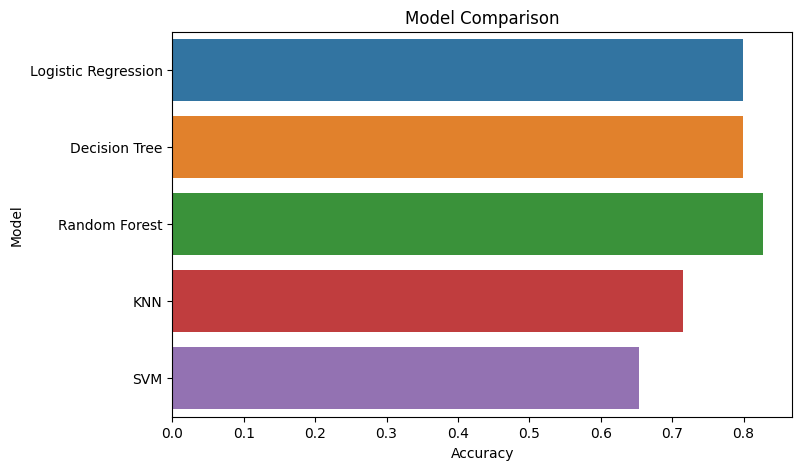

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.barplot(
    data=model_results,
    x="Accuracy",
    y="Model"
 )
plt.title("Model Comparison")
plt.show()

# Conclusion

- Multiple machine learning models were trained.
- Their performance was compared using accuracy.
- The best-performing model will be evaluated further in the next notebook.